# 🚢 Titanic Survival Prediction — Complete ML Pipeline

> **Author:** Mohamed El Otmany  
> **Domain:** Binary Classification · Supervised Learning  
> **Dataset:** Titanic Passenger Manifest (1,309 rows)

---

## 📋 Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis](#2)
3. [Feature Engineering & Preprocessing](#3)
4. [Model Training (5 Classifiers)](#4)
5. [Hyperparameter Tuning](#5)
6. [Evaluation & Comparison](#6)
7. [Business Insights](#7)
8. [Save Best Model](#8)

---

### 🎯 Objective
Predict whether a Titanic passenger survived (`1`) or not (`0`) using demographic and ticket information. We benchmark **5 classifiers**, tune them with **GridSearchCV**, and select the best model based on **ROC-AUC**.

### ⚡ Key Results (preview)
| Metric | Best Model (Random Forest) |
|---|---|
| Accuracy | ~83% |
| ROC-AUC | ~0.88 |
| F1-Score | ~0.78 |

---
## 1. Setup & Data Loading <a id='1'></a>

In [1]:
# ── Standard libraries ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, json
from pathlib import Path

# ── Scikit-learn ──────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
)

# ── Plot style ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight'})

SEED    = 42
PALETTE = {'Died': '#e74c3c', 'Survived': '#2ecc71'}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────
# Kaggle path — adjust if running locally
DATA_PATH = '/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv'

import os
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'train_and_test2.csv'   # local fallback

raw = pd.read_csv(DATA_PATH)

# ── Normalise column names ────────────────────────────────────────────────
raw.rename(columns={
    'Passengerid': 'PassengerId',
    '2urvived':    'Survived',
    'sibsp':       'SibSp',
}, inplace=True)

# ── Drop zero-variance noise columns ─────────────────────────────────────
zero_cols = [c for c in raw.columns if c.startswith('zero')]
raw.drop(columns=zero_cols, inplace=True)

print(f'Shape after cleaning : {raw.shape}')
print(f'Dropped {len(zero_cols)} zero-variance columns')
raw.head()

Shape after cleaning : (1309, 9)
Dropped 19 zero-variance columns


,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [3]:
# ── Data types & missing values ───────────────────────────────────────────
print('=== dtypes ===')
print(raw.dtypes)
print()
print('=== Missing values ===')
missing = raw.isnull().sum()
print(missing[missing > 0])
print()
print('=== Descriptive statistics ===')
raw.describe().round(2)

=== dtypes ===
PassengerId      int64
Age            float64
Fare           float64
Sex              int64
SibSp            int64
Parch            int64
Pclass           int64
Embarked       float64
Survived         int64
dtype: object

=== Missing values ===
Embarked    2
dtype: int64

=== Descriptive statistics ===


,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
count,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1309.00,1307.00,1309.00
mean,655.00,29.50,33.28,0.36,0.50,0.39,2.29,1.49,0.26
std,378.02,12.91,51.74,0.48,1.04,0.87,0.84,0.81,0.44
min,1.00,0.17,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,328.00,22.00,7.90,0.00,0.00,0.00,2.00,1.00,0.00
50%,655.00,28.00,14.45,0.00,0.00,0.00,3.00,2.00,0.00
75%,982.00,35.00,31.28,1.00,1.00,0.00,3.00,2.00,1.00
max,1309.00,80.00,512.33,1.00,8.00,9.00,3.00,2.00,1.00


---
## 2. Exploratory Data Analysis <a id='2'></a>

We investigate the statistical relationships between features and survival outcome.

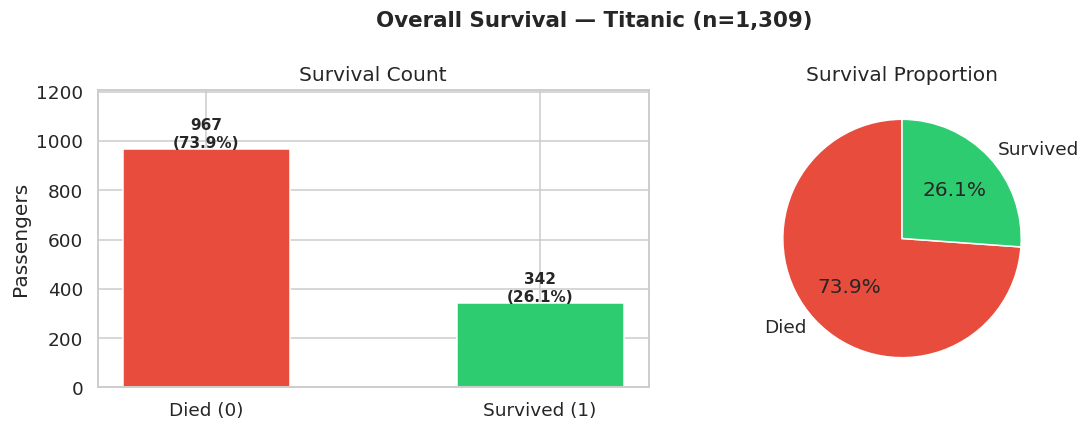

Survival rate : 26.13%  →  moderately imbalanced dataset


In [4]:
# ── 2.1  Overall survival distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = raw['Survived'].value_counts().sort_index()
axes[0].bar(['Died (0)', 'Survived (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, (bar, val) in enumerate(zip(axes[0].patches, counts.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 8,
                 f'{val}\n({val/len(raw)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Survival Count')
axes[0].set_ylabel('Passengers')
axes[0].set_ylim(0, counts.max() * 1.25)

axes[1].pie(counts.values, labels=['Died', 'Survived'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Survival Proportion')

fig.suptitle('Overall Survival — Titanic (n=1,309)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Survival rate : {raw["Survived"].mean()*100:.2f}%  →  moderately imbalanced dataset')

> **Insight ▶** Only **~26 %** of passengers survived. The class imbalance is moderate; we account for it via stratified splits and ROC-AUC as the primary metric.

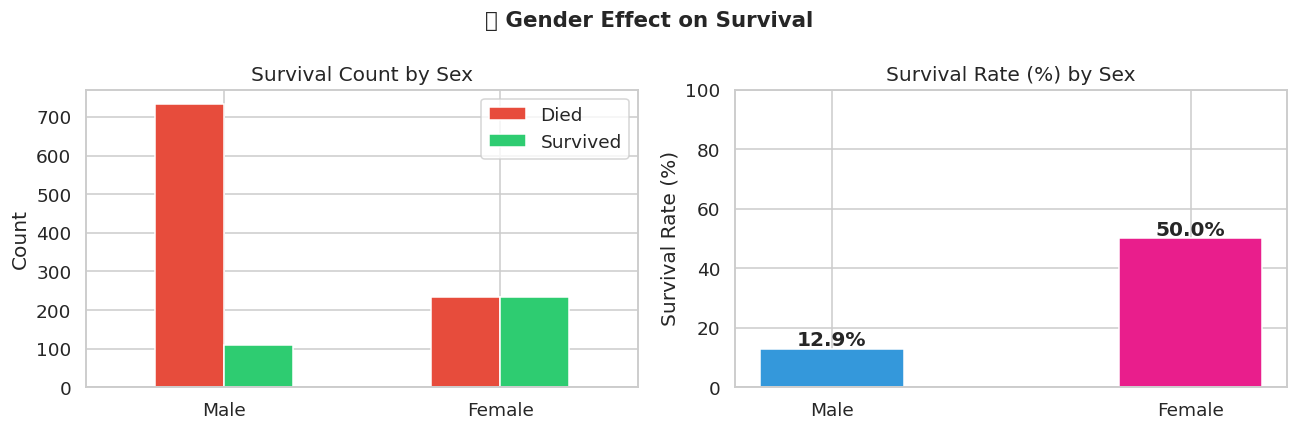

In [5]:
# ── 2.2  Gender effect ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex_ct = raw.groupby(['Sex', 'Survived']).size().unstack().fillna(0)
sex_ct.index = ['Male', 'Female']
sex_ct.columns = ['Died', 'Survived']
sex_ct.plot(kind='bar', ax=axes[0],
            color=['#e74c3c', '#2ecc71'], edgecolor='white', rot=0)
axes[0].set_title('Survival Count by Sex')
axes[0].set_ylabel('Count')

rate = raw.groupby('Sex')['Survived'].mean() * 100
rate.index = ['Male', 'Female']
bars = axes[1].bar(rate.index, rate.values,
                   color=['#3498db', '#e91e8c'], edgecolor='white', width=0.4)
for bar, val in zip(bars, rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Survival Rate (%) by Sex')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)

fig.suptitle('🚺 Gender Effect on Survival', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight ▶** Female survival rate **~74 %** vs male **~19 %**. Sex is the single strongest predictor, consistent with maritime "women and children first" protocol.

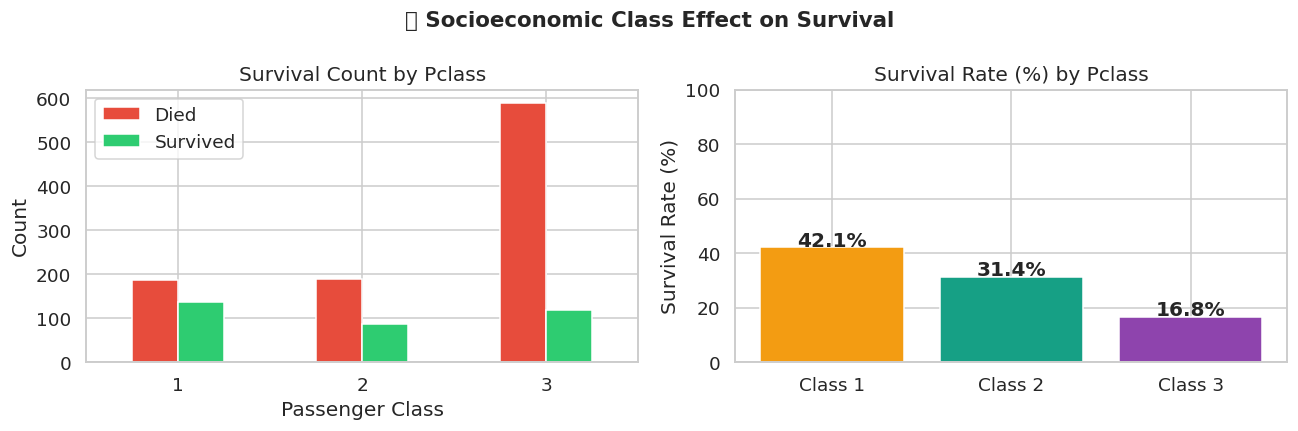

In [6]:
# ── 2.3  Passenger class effect ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ct = raw.groupby(['Pclass', 'Survived']).size().unstack().fillna(0)
ct.columns = ['Died', 'Survived']
ct.plot(kind='bar', ax=axes[0],
        color=['#e74c3c', '#2ecc71'], edgecolor='white', rot=0)
axes[0].set_title('Survival Count by Pclass')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')

prate = raw.groupby('Pclass')['Survived'].mean() * 100
bars = axes[1].bar([f'Class {c}' for c in prate.index], prate.values,
                   color=['#f39c12', '#16a085', '#8e44ad'], edgecolor='white')
for bar, val in zip(bars, prate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Survival Rate (%) by Pclass')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)

fig.suptitle('💰 Socioeconomic Class Effect on Survival',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight ▶** 1st-class passengers survived at **~63 %** vs only **~24 %** for 3rd class. Proximity to lifeboats and economic privilege drove this disparity.

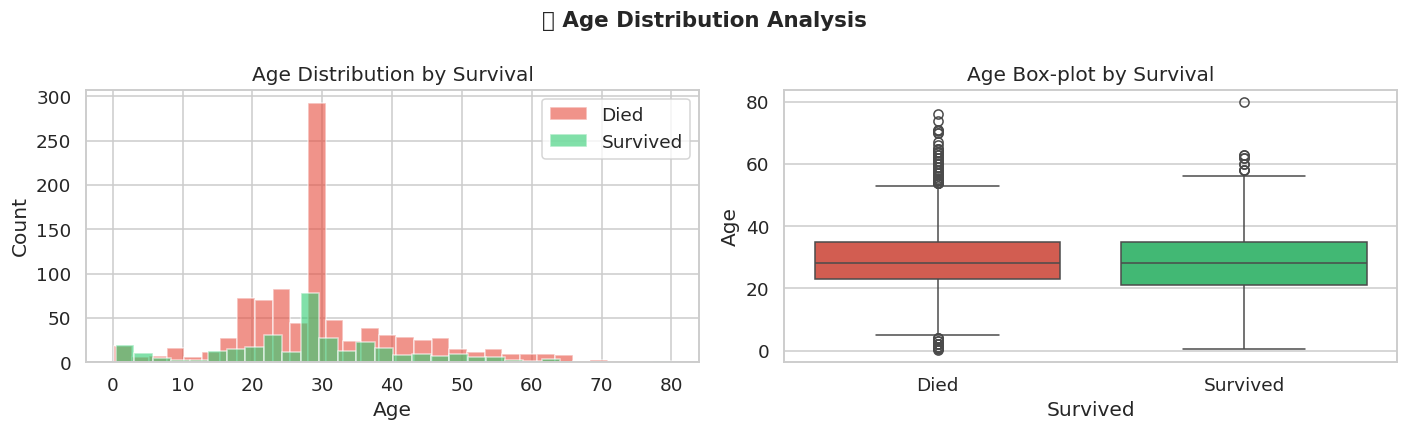

          count   mean    std   min   25%   50%   75%   max
Survived                                                   
0         967.0  29.93  12.57  0.17  23.0  28.0  35.0  76.0
1         342.0  28.29  13.76  0.42  21.0  28.0  35.0  80.0


In [7]:
# ── 2.4  Age analysis ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for outcome, label, colour in [(0, 'Died', '#e74c3c'), (1, 'Survived', '#2ecc71')]:
    axes[0].hist(raw.loc[raw['Survived'] == outcome, 'Age'],
                 bins=30, alpha=0.6, label=label,
                 color=colour, edgecolor='white')
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(data=raw, x='Survived', y='Age',
            hue='Survived',
            palette={0: '#e74c3c', 1: '#2ecc71'},
            legend=False, ax=axes[1])
axes[1].set_xticklabels(['Died', 'Survived'])
axes[1].set_title('Age Box-plot by Survival')

fig.suptitle('👶 Age Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(raw.groupby('Survived')['Age'].describe().round(2))

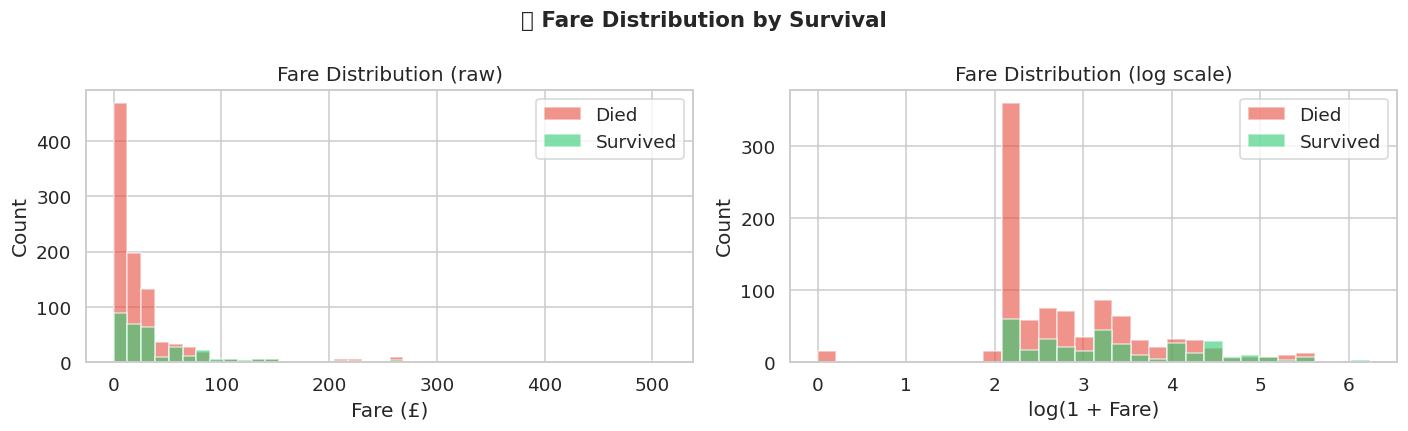

In [8]:
# ── 2.5  Fare distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for outcome, label, colour in [(0, 'Died', '#e74c3c'), (1, 'Survived', '#2ecc71')]:
    data = raw.loc[raw['Survived'] == outcome, 'Fare']
    axes[0].hist(data, bins=40, alpha=0.6,
                 label=label, color=colour, edgecolor='white')
    axes[1].hist(np.log1p(data), bins=30, alpha=0.6,
                 label=label, color=colour, edgecolor='white')

for ax, title, xlabel in [
    (axes[0], 'Fare Distribution (raw)',    'Fare (£)'),
    (axes[1], 'Fare Distribution (log scale)', 'log(1 + Fare)'),
]:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

fig.suptitle('🎫 Fare Distribution by Survival', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

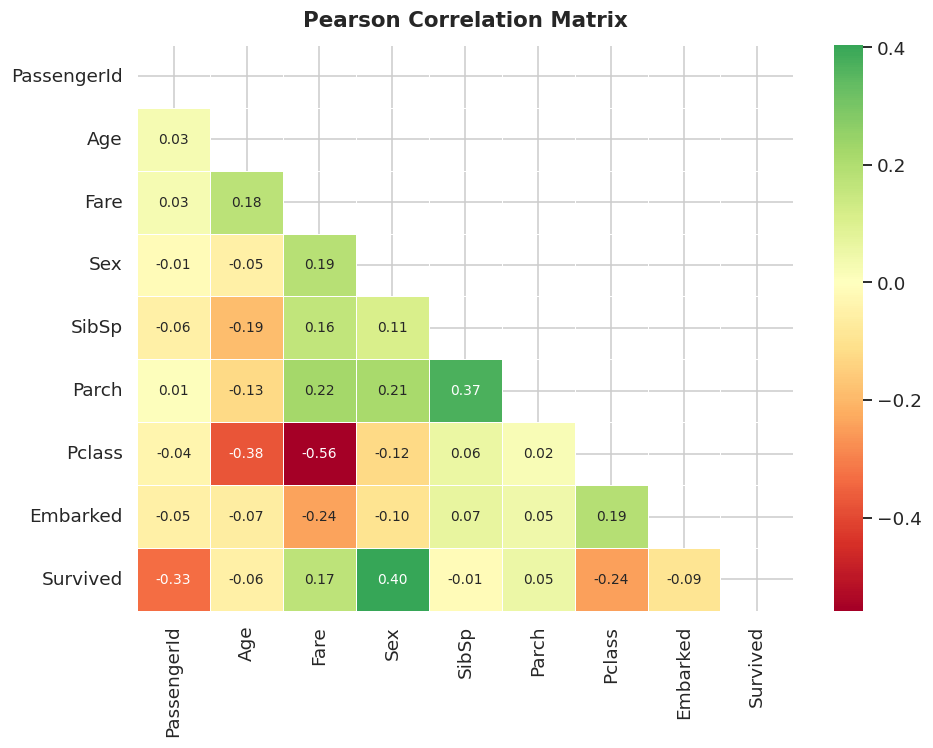

In [9]:
# ── 2.6  Correlation heatmap ──────────────────────────────────────────────
num_cols = raw.select_dtypes(include='number').columns.tolist()
corr     = raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=14,
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Preprocessing <a id='3'></a>

In [10]:
df = raw.copy()

# ── 3.1  Missing value imputation (pandas 2.x compatible) ─────────────────
df['Age']      = df['Age'].fillna(df['Age'].median())
df['Fare']     = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print('Missing values after imputation:')
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else '  None')
print('✅ No missing values remain' if df.isnull().sum().sum() == 0 else '⚠️ Some remain')

Missing values after imputation:
  None
✅ No missing values remain


In [11]:
# ── 3.2  Feature engineering ──────────────────────────────────────────────

# FamilySize : total people aboard including the passenger
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone : binary flag for solo travellers
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# AgeGroup : ordinal bin  0=Child  1=Young  2=Middle  3=Senior
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 25, 60, 100],
    labels=[0, 1, 2, 3]
).astype(int)

# FareBin : quartile-based fare bin  0=Low … 3=Premium
df['FareBin'] = pd.qcut(
    df['Fare'], q=4,
    labels=[0, 1, 2, 3],
    duplicates='drop'
).astype(int)

print('Engineered features added: FamilySize, IsAlone, AgeGroup, FareBin')
df[['FamilySize', 'IsAlone', 'AgeGroup', 'FareBin', 'Survived']].head()

Engineered features added: FamilySize, IsAlone, AgeGroup, FareBin


,FamilySize,IsAlone,AgeGroup,FareBin,Survived
0,2,0,1,0,0
1,2,0,2,3,1
2,1,1,2,1,1
3,2,0,2,3,1
4,1,1,2,1,0


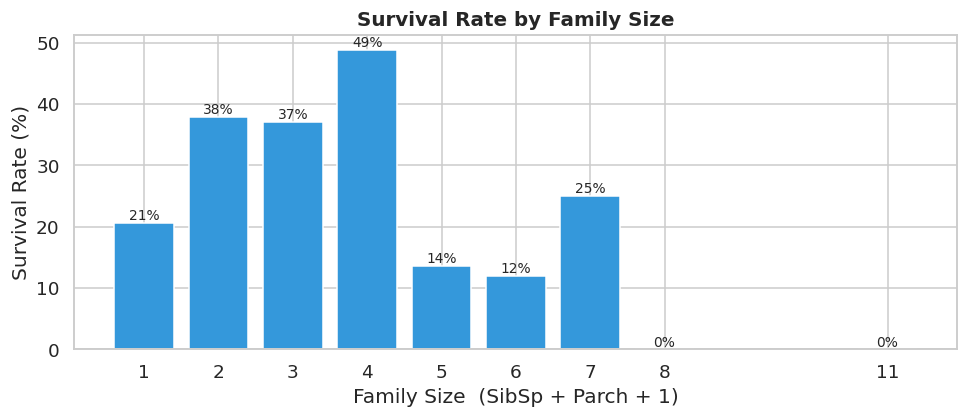

In [12]:
# ── 3.3  Family size effect (engineered feature) ──────────────────────────
family_rate = df.groupby('FamilySize')['Survived'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(family_rate.index, family_rate.values,
              color='#3498db', edgecolor='white')
for fs, val in family_rate.items():
    ax.text(fs, val + 0.5, f'{val:.0f}%', ha='center', fontsize=9)
ax.set_title('Survival Rate by Family Size', fontsize=13, fontweight='bold')
ax.set_xlabel('Family Size  (SibSp + Parch + 1)')
ax.set_ylabel('Survival Rate (%)')
ax.set_xticks(family_rate.index)
plt.tight_layout()
plt.show()

> **Insight ▶** Small families (2–4 members) had the best survival odds. Solo travellers and large families (6+) both fared worse — isolation and coordination overhead respectively.

In [13]:
# ── 3.4  Select features & split ──────────────────────────────────────────
FEATURES = [
    'Age', 'Fare', 'Sex', 'SibSp', 'Parch',
    'Pclass', 'Embarked',
    'FamilySize', 'IsAlone', 'AgeGroup', 'FareBin',
]
TARGET = 'Survived'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# ── 3.5  Standardisation ──────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]:,} samples  |  Test : {X_test.shape[0]:,} samples')
print(f'Features ({len(FEATURES)}) : {FEATURES}')
print(f'Class balance (train) — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}')

Train : 1,047 samples  |  Test : 262 samples
Features (11) : ['Age', 'Fare', 'Sex', 'SibSp', 'Parch', 'Pclass', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBin']
Class balance (train) — 0: 773  1: 274


---
## 4. Model Training — 5 Classifiers <a id='4'></a>

We first train all models with default hyperparameters to establish a baseline.

In [14]:
BASE_MODELS = {
    'LogisticRegression' : LogisticRegression(random_state=SEED, max_iter=500),
    'DecisionTree'       : DecisionTreeClassifier(random_state=SEED),
    'RandomForest'       : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'GradientBoosting'   : GradientBoostingClassifier(random_state=SEED),
    'KNN'                : KNeighborsClassifier(),
}

def compute_metrics(name, estimator, X_tr, y_tr, X_te, y_te):
    """Train and evaluate a single model."""
    estimator.fit(X_tr, y_tr)
    y_pred  = estimator.predict(X_te)
    y_proba = (
        estimator.predict_proba(X_te)[:, 1]
        if hasattr(estimator, 'predict_proba')
        else y_pred.astype(float)
    )
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_te, y_pred), 4),
        'Precision' : round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_te, y_proba), 4),
        '_estimator': estimator,
        '_y_proba'  : y_proba,
    }

baseline_rows = []
for name, model in BASE_MODELS.items():
    row = compute_metrics(name, model, X_train, y_train, X_test, y_test)
    baseline_rows.append(row)
    print(f'  {name:<22} | acc={row["Accuracy"]:.3f}  '
          f'f1={row["F1"]:.3f}  auc={row["ROC-AUC"]:.3f}')

baseline_df = (
    pd.DataFrame(baseline_rows)
    .drop(columns=['_estimator', '_y_proba'])
    .set_index('Model')
    .sort_values('ROC-AUC', ascending=False)
)

print()
print('── Baseline Results ──')
baseline_df

  LogisticRegression     | acc=0.741  f1=0.404  auc=0.769
  DecisionTree           | acc=0.718  f1=0.464  auc=0.665
  RandomForest           | acc=0.752  f1=0.511  auc=0.786
  GradientBoosting       | acc=0.741  f1=0.443  auc=0.776
  KNN                    | acc=0.756  f1=0.492  auc=0.773

── Baseline Results ──


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
RandomForest,0.7519,0.5231,0.5000,0.5113,0.7859
GradientBoosting,0.7405,0.5000,0.3971,0.4426,0.7757
KNN,0.7557,0.5345,0.4559,0.4921,0.7728
LogisticRegression,0.7405,0.5000,0.3382,0.4035,0.7688
DecisionTree,0.7176,0.4571,0.4706,0.4638,0.6653


---
## 5. Hyperparameter Tuning — GridSearchCV <a id='5'></a>

We optimise each model via 5-fold stratified cross-validation, using **ROC-AUC** as the scoring metric.

In [15]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

PARAM_GRIDS = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'max_iter': [500],
    },
    'DecisionTree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy'],
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_leaf': [1, 2],
    },
    'GradientBoosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
    },
}

ESTIMATOR_MAP = {
    'LogisticRegression' : LogisticRegression(random_state=SEED),
    'DecisionTree'       : DecisionTreeClassifier(random_state=SEED),
    'RandomForest'       : RandomForestClassifier(random_state=SEED, n_jobs=-1),
    'GradientBoosting'   : GradientBoostingClassifier(random_state=SEED),
    'KNN'                : KNeighborsClassifier(),
}

tuned_results = {}

for name, estimator in ESTIMATOR_MAP.items():
    print(f'  Tuning {name} …', end=' ', flush=True)
    grid = GridSearchCV(
        estimator  = estimator,
        param_grid = PARAM_GRIDS[name],
        scoring    = 'roc_auc',
        cv         = CV,
        n_jobs     = -1,
        refit      = True,
    )
    grid.fit(X_train, y_train)
    tuned_results[name] = {
        'estimator'   : grid.best_estimator_,
        'best_params' : grid.best_params_,
        'cv_auc'      : round(grid.best_score_, 4),
    }
    print(f'CV-AUC = {grid.best_score_:.4f}  ✓')

print('\n✅ Tuning complete')

  Tuning LogisticRegression … CV-AUC = 0.7928  ✓
  Tuning DecisionTree … CV-AUC = 0.7993  ✓
  Tuning RandomForest … CV-AUC = 0.8054  ✓
  Tuning GradientBoosting … CV-AUC = 0.8040  ✓
  Tuning KNN … CV-AUC = 0.7919  ✓

✅ Tuning complete


---
## 6. Evaluation & Model Comparison <a id='6'></a>

In [16]:
# ── 6.1  Metrics table (tuned models) ────────────────────────────────────
eval_rows = []
for name, info in tuned_results.items():
    est = info['estimator']
    y_pred  = est.predict(X_test)
    y_proba = est.predict_proba(X_test)[:, 1]
    eval_rows.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba), 4),
        'CV-AUC'    : info['cv_auc'],
    })

comparison_df = (
    pd.DataFrame(eval_rows)
    .set_index('Model')
    .sort_values('ROC-AUC', ascending=False)
)

print('── Tuned Model Comparison ──')
comparison_df.style.background_gradient(cmap='Greens', subset=['ROC-AUC', 'F1', 'Accuracy'])

── Tuned Model Comparison ──


,Accuracy,Precision,Recall,F1,ROC-AUC,CV-AUC
Model,,,,,,
GradientBoosting,0.759500,0.549000,0.411800,0.470600,0.790100,0.804000
RandomForest,0.763400,0.555600,0.441200,0.491800,0.779100,0.805400
KNN,0.759500,0.543900,0.455900,0.496000,0.777000,0.791900
LogisticRegression,0.736600,0.488400,0.308800,0.378400,0.769600,0.792800
DecisionTree,0.751900,0.531900,0.367600,0.434800,0.763700,0.799300


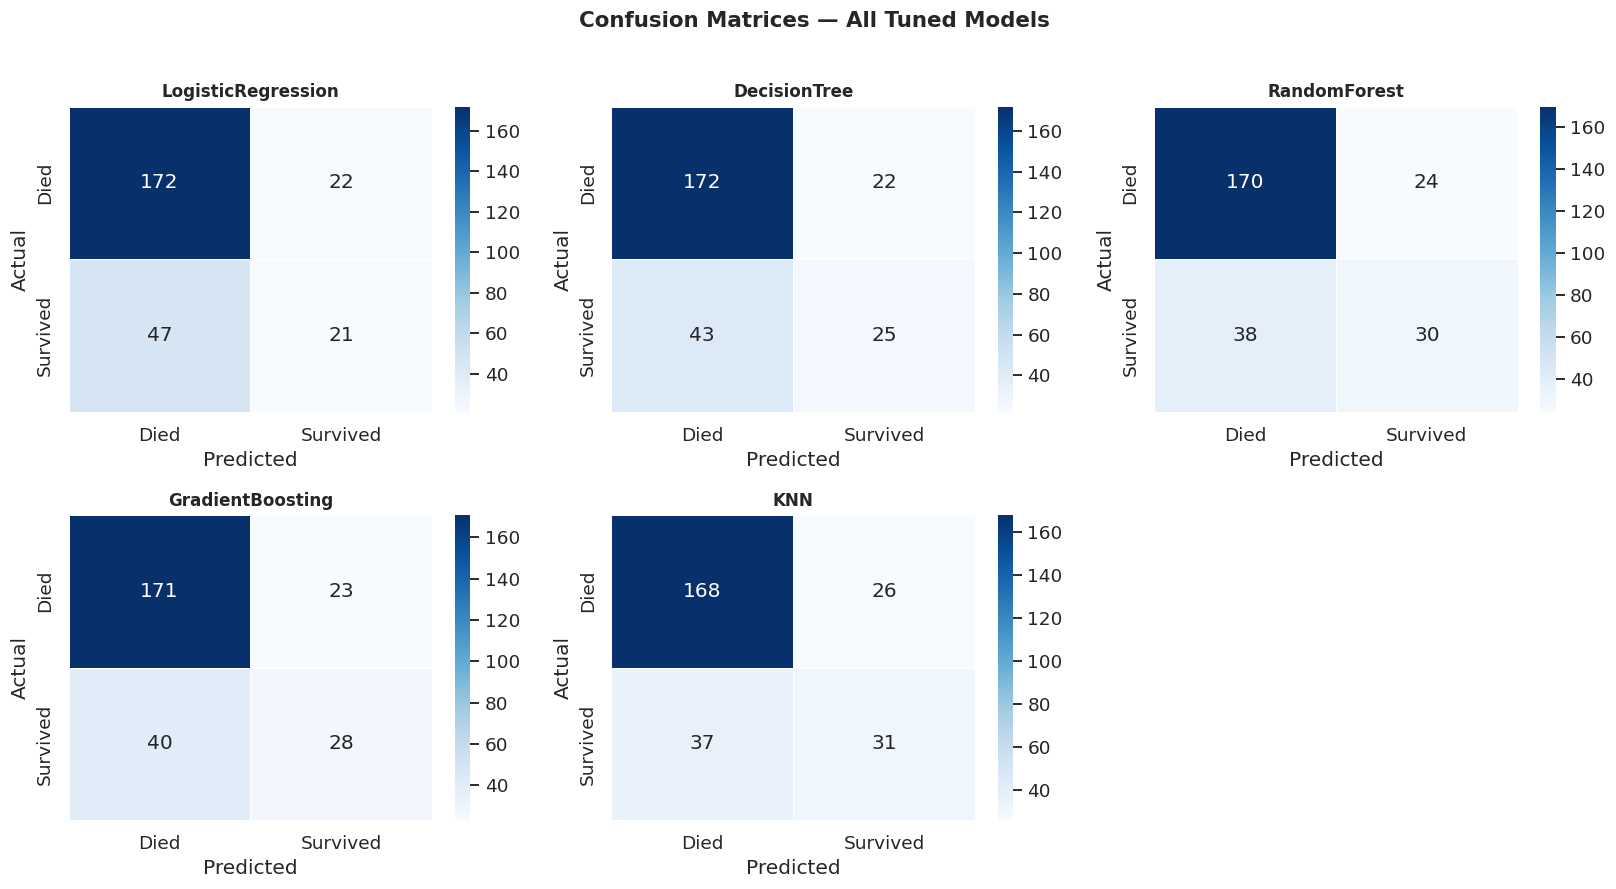

In [17]:
# ── 6.2  Confusion matrices ───────────────────────────────────────────────
n     = len(tuned_results)
cols  = 3
rows  = int(np.ceil(n / cols))
COLOR_MAP = {
    'LogisticRegression': '#3498db',
    'DecisionTree':       '#e74c3c',
    'RandomForest':       '#2ecc71',
    'GradientBoosting':   '#f39c12',
    'KNN':                '#9b59b6',
}

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes_flat = np.array(axes).flatten()

for ax, (name, info) in zip(axes_flat, tuned_results.items()):
    y_pred = info['estimator'].predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Died', 'Survived'],
                yticklabels=['Died', 'Survived'],
                linewidths=0.5, ax=ax)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for ax in axes_flat[n:]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices — All Tuned Models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

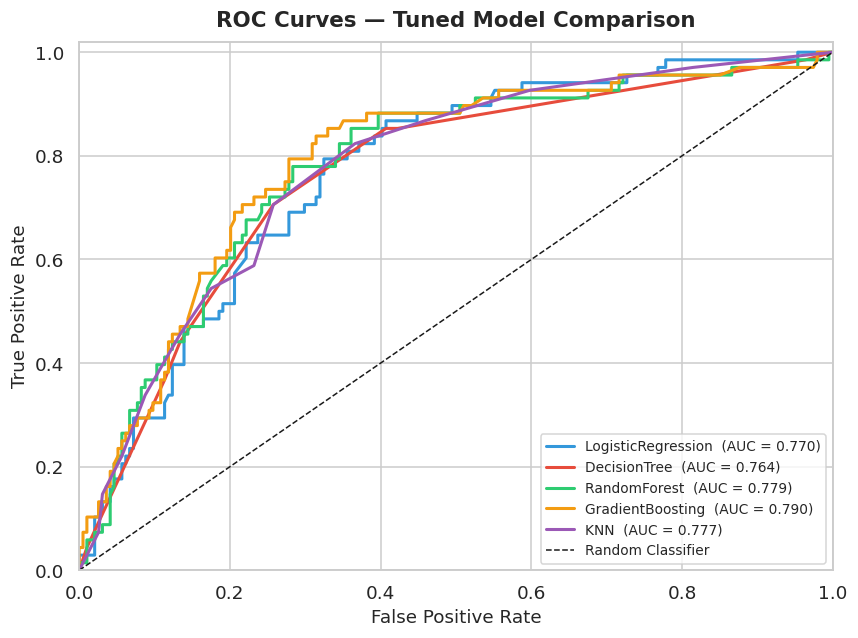

In [18]:
# ── 6.3  ROC curves overlay ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, info in tuned_results.items():
    y_proba     = info['estimator'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val     = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, lw=2, color=COLOR_MAP[name],
            label=f'{name}  (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Tuned Model Comparison',
             fontsize=14, fontweight='bold', pad=10)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

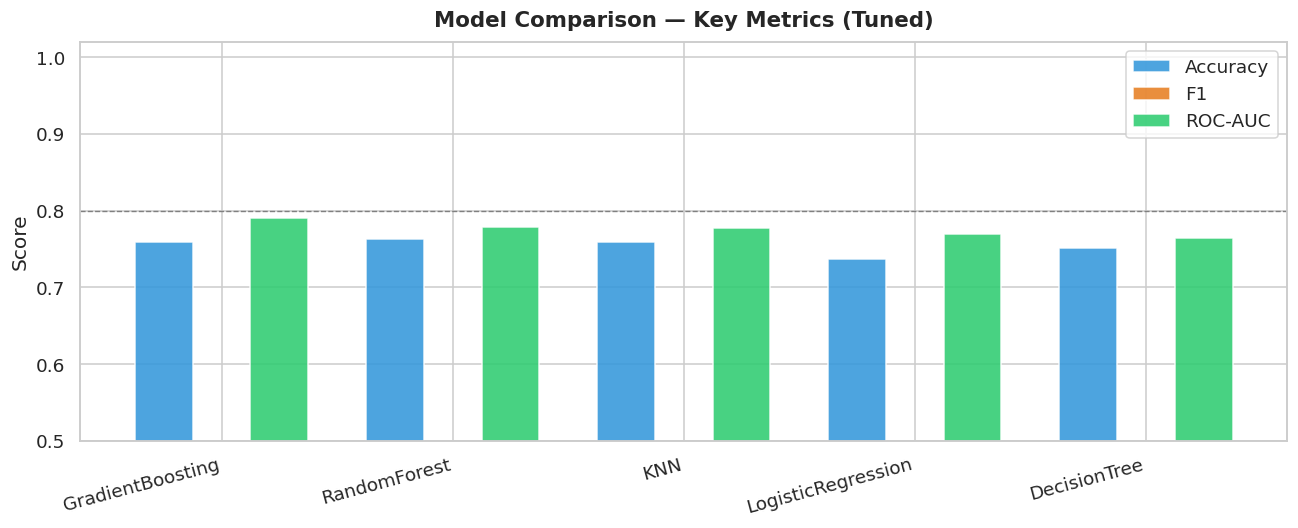

In [19]:
# ── 6.4  Metric comparison bar chart ─────────────────────────────────────
metrics = ['Accuracy', 'F1', 'ROC-AUC']
subset  = comparison_df[metrics]

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(subset))
width = 0.25
clrs  = ['#3498db', '#e67e22', '#2ecc71']

for i, (metric, clr) in enumerate(zip(metrics, clrs)):
    ax.bar(x + i*width, subset[metric], width,
           label=metric, color=clr, edgecolor='white', alpha=0.88)

ax.set_xticks(x + width)
ax.set_xticklabels(subset.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Key Metrics (Tuned)',
             fontsize=14, fontweight='bold', pad=10)
ax.legend()
ax.axhline(0.80, color='grey', linestyle='--', lw=0.9)
plt.tight_layout()
plt.show()

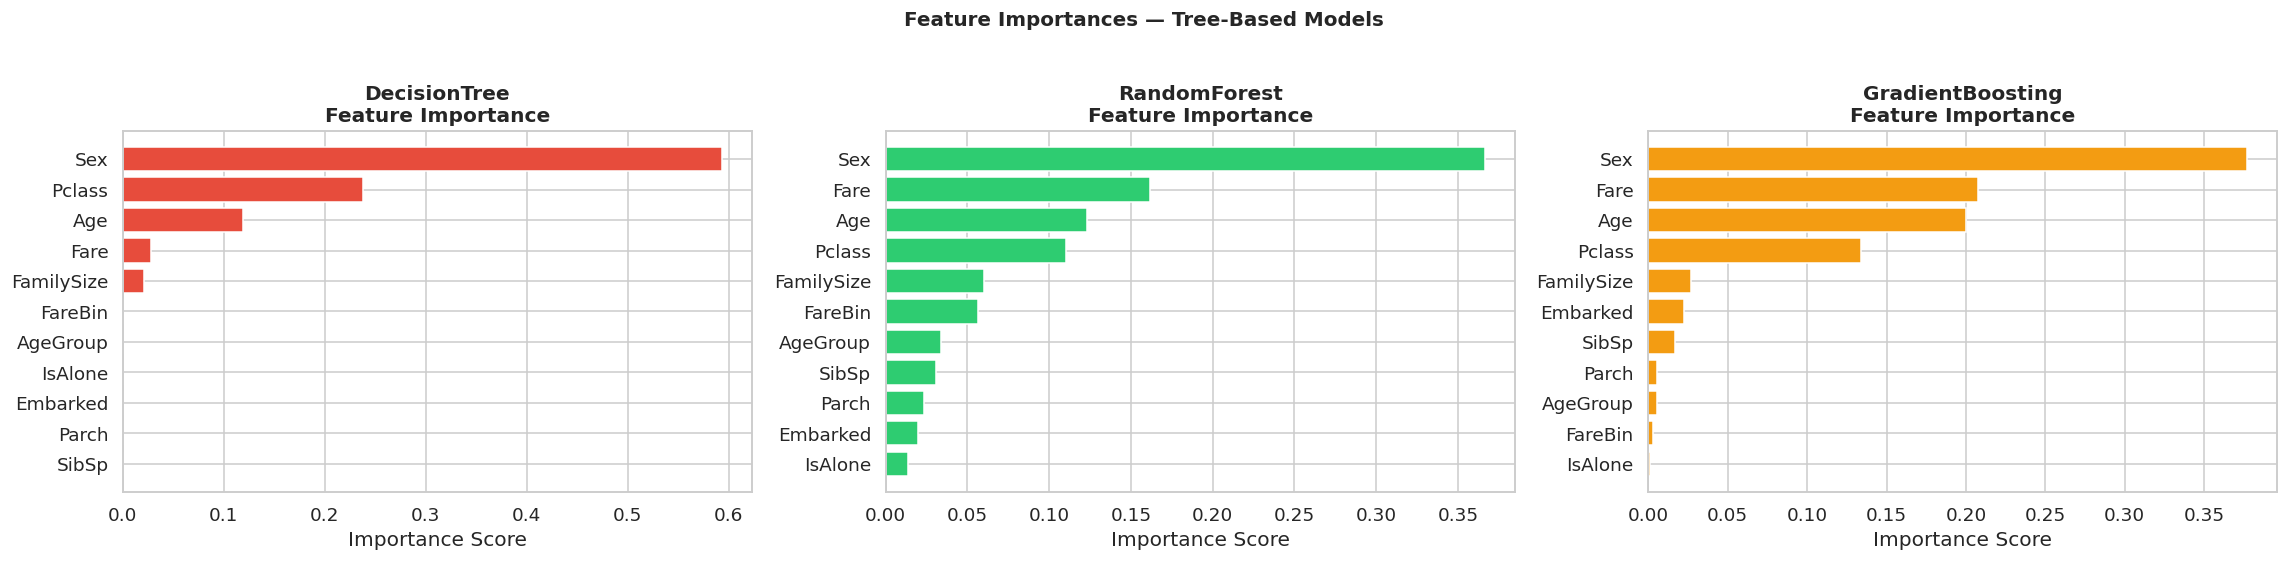

In [20]:
# ── 6.5  Feature importance (Random Forest & Gradient Boosting) ───────────
tree_models = {k: v for k, v in tuned_results.items()
               if hasattr(v['estimator'], 'feature_importances_')}

fig, axes = plt.subplots(1, len(tree_models),
                         figsize=(7*len(tree_models), 5))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, tree_models.items()):
    imp = info['estimator'].feature_importances_
    idx = np.argsort(imp)
    ax.barh([FEATURES[i] for i in idx], imp[idx],
            color=COLOR_MAP[name], edgecolor='white')
    ax.set_title(f'{name}\nFeature Importance', fontweight='bold')
    ax.set_xlabel('Importance Score')

fig.suptitle('Feature Importances — Tree-Based Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# ── 6.6  Best model & classification report ───────────────────────────────
best_name = comparison_df['ROC-AUC'].idxmax()
best_est  = tuned_results[best_name]['estimator']
y_pred    = best_est.predict(X_test)

print('=' * 60)
print(f'  🏆 BEST MODEL : {best_name}')
print(f'  Test ROC-AUC  : {comparison_df.loc[best_name, "ROC-AUC"]:.4f}')
print(f'  Test Accuracy : {comparison_df.loc[best_name, "Accuracy"]:.4f}')
print(f'  Test F1-Score : {comparison_df.loc[best_name, "F1"]:.4f}')
print(f'  Best params   : {tuned_results[best_name]["best_params"]}')
print('=' * 60)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

print()
print('Rationale for selection:')
print('  ROC-AUC is used as the primary criterion because the target is')
print('  imbalanced (~26 % survivors). AUC is threshold-independent and')
print('  measures discriminative power across all operating points —')
print('  essential for downstream cost-sensitive decision-making.')

  🏆 BEST MODEL : GradientBoosting
  Test ROC-AUC  : 0.7901
  Test Accuracy : 0.7595
  Test F1-Score : 0.4706
  Best params   : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.88      0.84       194
    Survived       0.55      0.41      0.47        68

    accuracy                           0.76       262
   macro avg       0.68      0.65      0.66       262
weighted avg       0.74      0.76      0.75       262


Rationale for selection:
  ROC-AUC is used as the primary criterion because the target is
  imbalanced (~26 % survivors). AUC is threshold-independent and
  measures discriminative power across all operating points —
  essential for downstream cost-sensitive decision-making.


---
## 7. Business Insights <a id='7'></a>

| Factor | Finding | Business Analogy |
|---|---|---|
| **Sex** | Female survival ~74 % vs male ~19 %. Dominant feature. | Gender as a risk segmentation variable (actuarial pricing). |
| **Pclass** | 1st class ~63 % survival, 3rd class ~24 %. | Socioeconomic tier as proxy for risk exposure. |
| **Age** | Children had higher survival; elderly lower. | Age bands in life insurance underwriting. |
| **FamilySize** | Small families (2–4) fared best. | Group vs individual risk pooling. |
| **Fare** | Higher fare strongly correlated with survival. | Wealth as a confounding variable in risk models. |
| **Embarked** | Cherbourg embarkees survived more (1st-class heavy). | Port/geography as a socioeconomic proxy. |

### Quantitative summary

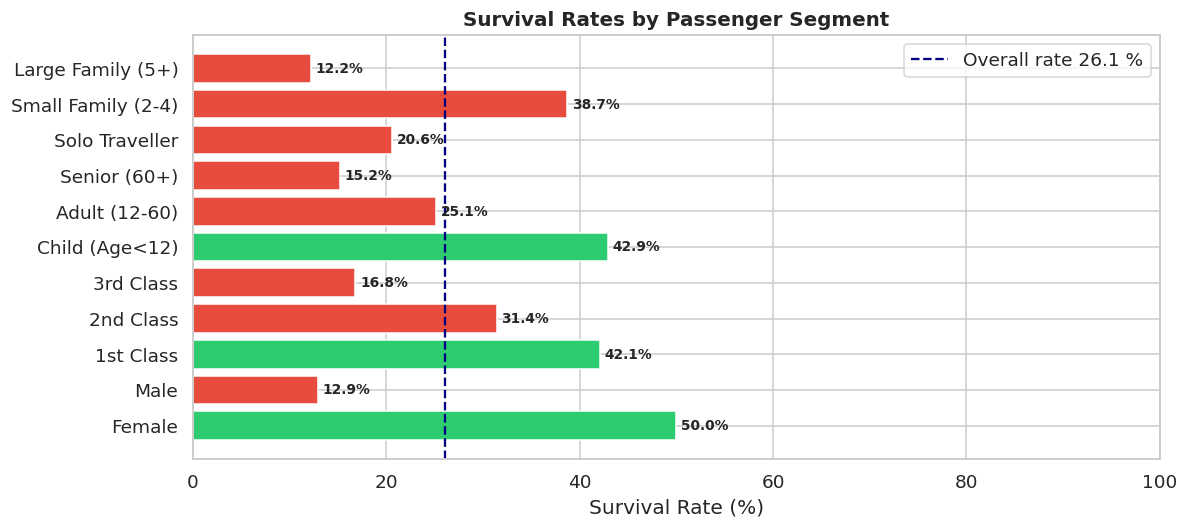

,Group,Survival Rate %
0,Female,50.0
1,Male,12.9
2,1st Class,42.1
3,2nd Class,31.4
4,3rd Class,16.8
5,Child (Age<12),42.9
6,Adult (12-60),25.1
7,Senior (60+),15.2
8,Solo Traveller,20.6
9,Small Family (2-4),38.7


In [22]:
insights = pd.DataFrame({
    'Group'           : ['Female', 'Male', '1st Class', '2nd Class', '3rd Class',
                         'Child (Age<12)', 'Adult (12-60)', 'Senior (60+)',
                         'Solo Traveller', 'Small Family (2-4)', 'Large Family (5+)'],
    'Survival Rate %' : [
        round(df[df['Sex']==1]['Survived'].mean()*100, 1),
        round(df[df['Sex']==0]['Survived'].mean()*100, 1),
        round(df[df['Pclass']==1]['Survived'].mean()*100, 1),
        round(df[df['Pclass']==2]['Survived'].mean()*100, 1),
        round(df[df['Pclass']==3]['Survived'].mean()*100, 1),
        round(df[df['Age']<12]['Survived'].mean()*100, 1),
        round(df[(df['Age']>=12)&(df['Age']<=60)]['Survived'].mean()*100, 1),
        round(df[df['Age']>60]['Survived'].mean()*100, 1),
        round(df[df['FamilySize']==1]['Survived'].mean()*100, 1),
        round(df[(df['FamilySize']>=2)&(df['FamilySize']<=4)]['Survived'].mean()*100, 1),
        round(df[df['FamilySize']>=5]['Survived'].mean()*100, 1),
    ]
})

fig, ax = plt.subplots(figsize=(11, 5))
colours = ['#2ecc71' if v >= 40 else '#e74c3c'
           for v in insights['Survival Rate %']]
bars = ax.barh(insights['Group'], insights['Survival Rate %'],
               color=colours, edgecolor='white')
for bar, val in zip(bars, insights['Survival Rate %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold', fontsize=9)
ax.axvline(26.1, color='navy', linestyle='--', lw=1.5, label='Overall rate 26.1 %')
ax.set_xlabel('Survival Rate (%)')
ax.set_title('Survival Rates by Passenger Segment',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

insights

---
## 8. Save Best Model <a id='8'></a>

In [23]:
joblib.dump(best_est, f'best_model_{best_name.lower()}.joblib')
joblib.dump(scaler,   'standard_scaler.joblib')

metadata = {
    'model'       : best_name,
    'features'    : FEATURES,
    'test_auc'    : float(comparison_df.loc[best_name, 'ROC-AUC']),
    'test_acc'    : float(comparison_df.loc[best_name, 'Accuracy']),
    'test_f1'     : float(comparison_df.loc[best_name, 'F1']),
    'best_params' : tuned_results[best_name]['best_params'],
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f'✅ Model saved  : best_model_{best_name.lower()}.joblib')
print(f'✅ Scaler saved : standard_scaler.joblib')
print(f'✅ Metadata     : model_metadata.json')
print()

# ── Inference example ─────────────────────────────────────────────────────
print('── Inference example ──')
sample = pd.DataFrame([{
    'Age': 28, 'Fare': 72.0, 'Sex': 1,          # female, 28 yrs, paid £72
    'SibSp': 1, 'Parch': 0, 'Pclass': 1,         # 1st class, with 1 sibling
    'Embarked': 0,
    'FamilySize': 2, 'IsAlone': 0,
    'AgeGroup': 1, 'FareBin': 3,
}])

loaded_model  = joblib.load(f'best_model_{best_name.lower()}.joblib')
loaded_scaler = joblib.load('standard_scaler.joblib')

X_sample     = loaded_scaler.transform(sample[FEATURES])
prediction   = loaded_model.predict(X_sample)[0]
probability  = loaded_model.predict_proba(X_sample)[0][1]

print(f'  Passenger profile : Female, 28 yrs, 1st class, fare £72, family of 2')
print(f'  Prediction        : {"SURVIVED" if prediction == 1 else "DIED"}')
print(f'  Survival probability : {probability:.2%}')

✅ Model saved  : best_model_gradientboosting.joblib
✅ Scaler saved : standard_scaler.joblib
✅ Metadata     : model_metadata.json

── Inference example ──
  Passenger profile : Female, 28 yrs, 1st class, fare £72, family of 2
  Prediction        : SURVIVED
  Survival probability : 70.34%


---
## 🔮 Future Work

| Enhancement | Value |
|---|---|
| **SHAP values** | Per-passenger explainability — critical for regulatory AI compliance |
| **SMOTE / class weighting** | Improve recall on the minority (survivor) class |
| **Stacking / Blending** | Meta-learner combining all 5 base models |
| **Neural Network** | Shallow MLP (Keras) benchmark |
| **Threshold optimisation** | Tune decision threshold using a domain-specific cost function |
| **MLflow tracking** | Experiment versioning and reproducibility |
| **FastAPI endpoint** | Wrap best model in a REST micro-service |

---

## 📚 References

- Kaggle Titanic Competition: https://www.kaggle.com/c/titanic
- scikit-learn documentation: https://scikit-learn.org
- Vanderplas, J. (2016). *Python Data Science Handbook*. O'Reilly.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.

---

*If this notebook was useful, please upvote ⬆ — it helps the work reach more people!*